<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/3_Flavour_oscillation(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import matplotlib as mpl
mpl.rcParams.update({
    "figure.figsize":   (10, 6),
    "font.size":        16,
    "axes.titlesize":   22,
    "axes.labelsize":   18,
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
    "legend.fontsize":  16,
    "grid.linewidth":   0.8
})

# Global conversion and matter constants
CONV_KM_TO_INV_EV = 5.067731e9    # km → 1/eV conversion factor
VCC_EARTH_CRUST = 7.6e-14         # Matter potential (eV)

# Standard three-flavor parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0                     # CP-phase (set to 0 or change as needed)
D21 = 7.39e-5                   # eV² (solar)
D31 = 2.525e-3                  # eV² (atmospheric)

# Additional four-flavor parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0                     # extra CP-phase
D41 = 1.0                       # eV² (sterile)

# Baseline for Near Detector (ND)
Length_near = 1  # km

# Energy range: 0.5 GeV to 5 GeV (energies in GeV and converted to eV)
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9


Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 6.85 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/src/NuOscProbExact/src/NuOscProbExact/src
globaldefs.py       hamiltonians3nu.py  oscprob3nu.py
hamiltonians2nu.py  oscprob2nu.py


In [ ]:
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                            delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conjugate(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vac, E, VCC):
    return H_vac + np.diag([VCC, 0, 0, 0])

def probability_4nu(energy, L, transition='mm', case='vacuum'):
    # energy in eV, L in km
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        H = hamiltonian_4nu_matter(H_vac, energy, VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':   # μ → μ: use index 1 (muon flavor)
        return np.abs(S[1, 1])**2
    elif transition == 'me': # μ → e: index 0
        return np.abs(S[1, 0])**2
    elif transition == 'mt': # μ → τ: index 2
        return np.abs(S[1, 2])**2
    elif transition == 'ms': # μ → sterile: index 3
        return np.abs(S[1, 3])**2


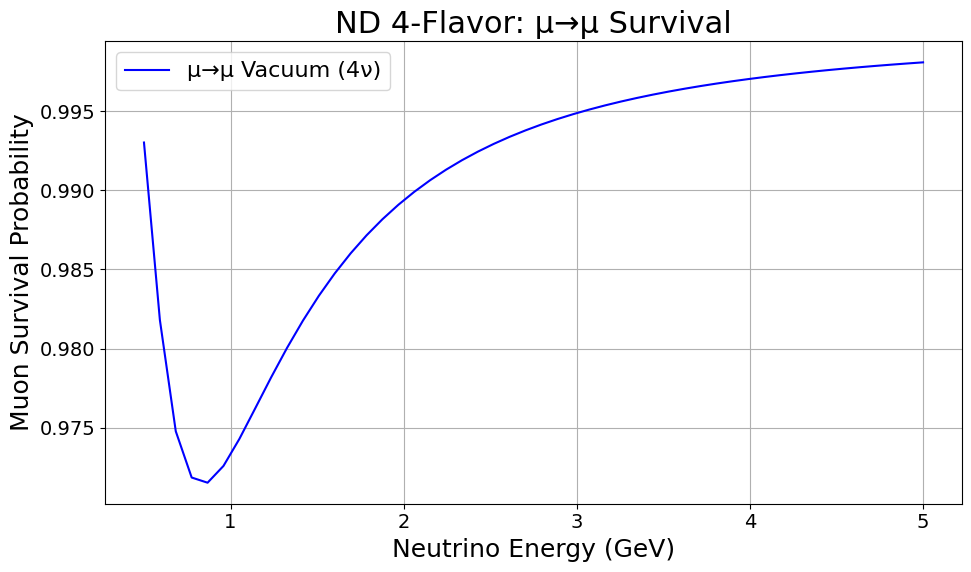

In [ ]:
# Compute μ→μ (muon survival) probabilities for 4ν at ND (L = 1 km)
probs_mm_vac_nd = [probability_4nu(E, Length_near, transition='mm', case='vacuum') for E in energies_eV]
probs_mm_mat_nd = [probability_4nu(E, Length_near, transition='mm', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_mm_vac_nd, 'b-', label="μ→μ Vacuum (4ν)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("ND 4-Flavor: μ→μ Survival")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


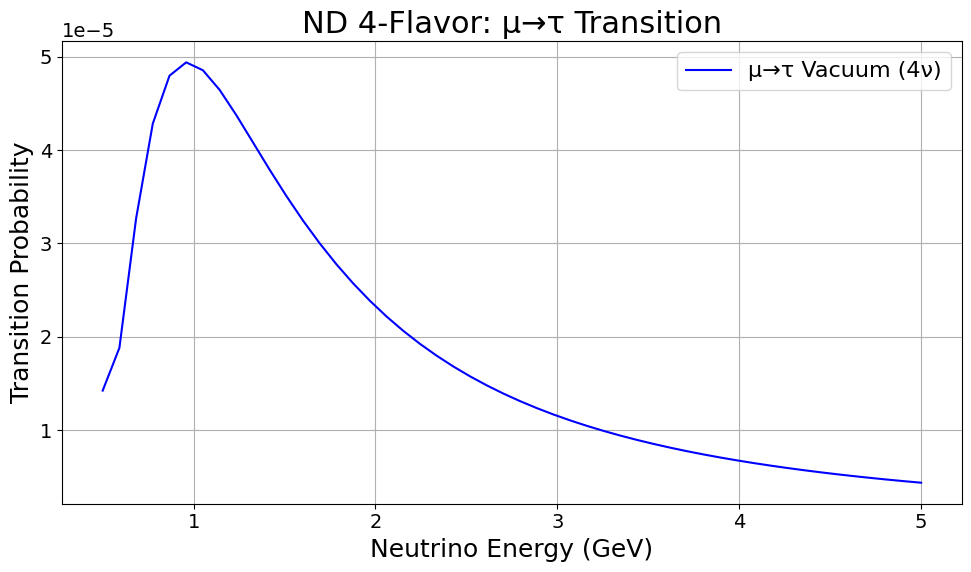

In [ ]:
# Compute μ→τ (muon to tau) probabilities for 4ν at ND (L = 1 km)
probs_mt_vac_nd = [probability_4nu(E, Length_near, transition='mt', case='vacuum') for E in energies_eV]
probs_mt_mat_nd = [probability_4nu(E, Length_near, transition='mt', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_mt_vac_nd, 'b-', label="μ→τ Vacuum (4ν)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Transition Probability")
plt.title("ND 4-Flavor: μ→τ Transition")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


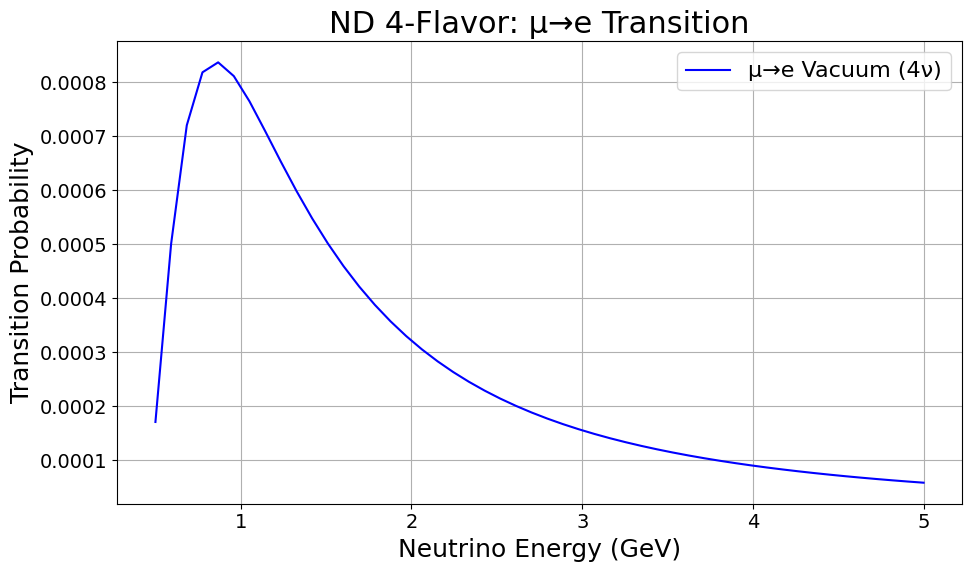

In [ ]:
# Compute μ→e (muon to electron) probabilities for 4ν at ND (L = 1 km)
probs_me_vac_nd = [probability_4nu(E, Length_near, transition='me', case='vacuum') for E in energies_eV]
probs_me_mat_nd = [probability_4nu(E, Length_near, transition='me', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_me_vac_nd, 'b-', label="μ→e Vacuum (4ν)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Transition Probability")
plt.title("ND 4-Flavor: μ→e Transition")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


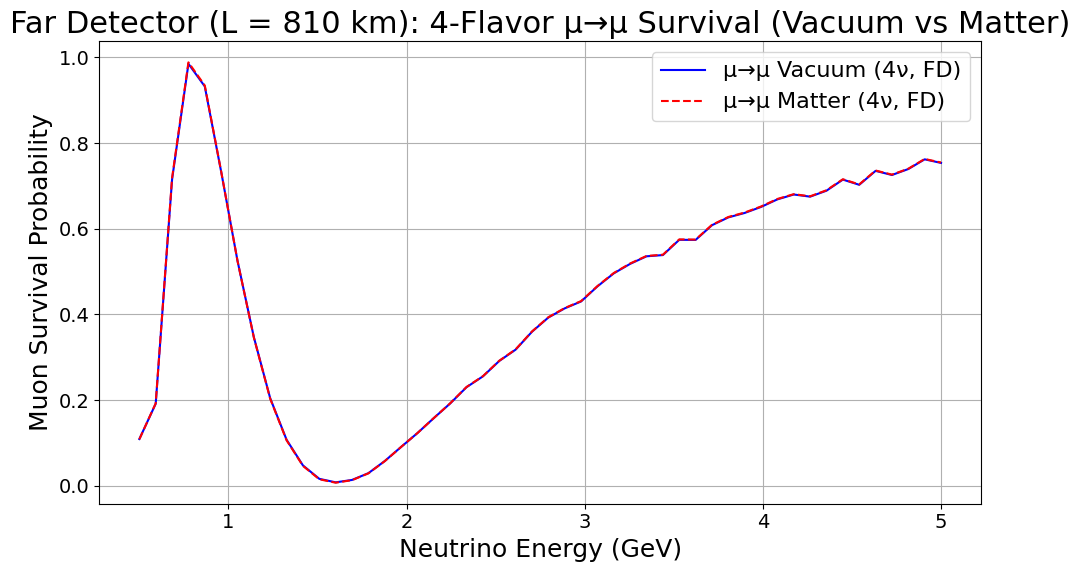

In [ ]:
# Set the Far Detector baseline
Length_far = 810  # km

# Define the energy range in GeV and convert to eV
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9

# Compute 4-flavor muon survival probability (νμ → νμ) for the Far Detector,
# in both vacuum and matter conditions.
probs_mm_vac_fd = [probability_4nu(E, Length_far, transition='mm', case='vacuum') for E in energies_eV]
probs_mm_mat_fd = [probability_4nu(E, Length_far, transition='mm', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_mm_vac_fd, 'b-', label="μ→μ Vacuum (4ν, FD)")
plt.plot(energies_GeV, probs_mm_mat_fd, 'r--', label="μ→μ Matter (4ν, FD)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("Far Detector (L = 810 km): 4-Flavor μ→μ Survival (Vacuum vs Matter)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


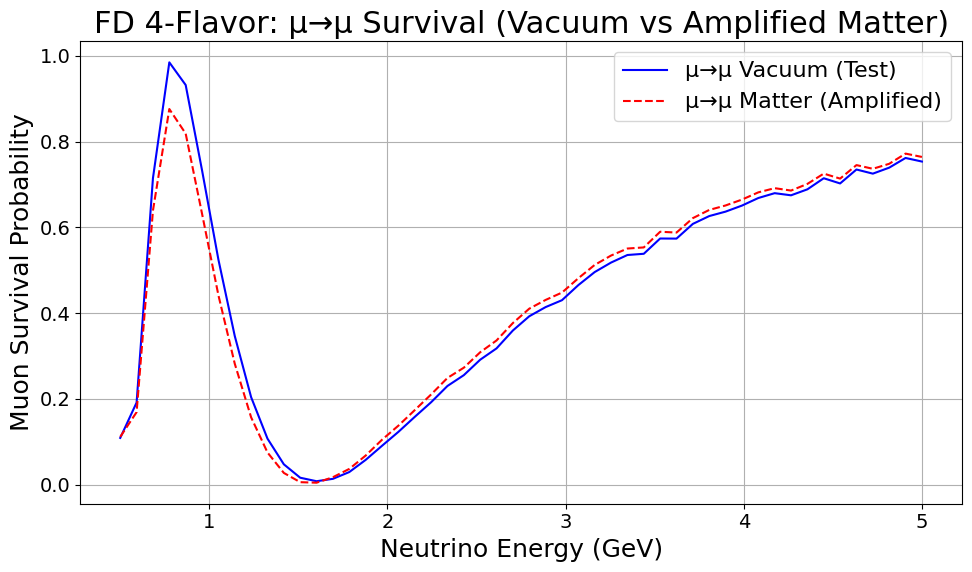

In [ ]:
# Temporarily amplify the matter potential for testing:
VCC_test = 10 * VCC_EARTH_CRUST

def probability_4nu_test(energy, L, transition='mm', case='vacuum'):
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        # Use the amplified potential for testing:
        H = hamiltonian_4nu_matter(H_vac, energy, VCC_test)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2
    elif transition == 'ms':
        return np.abs(S[1, 3])**2

# Now compute with the test function at FD to see a larger matter effect
Length_far = 810  # km
probs_mm_vac_test = [probability_4nu_test(E, Length_far, transition='mm', case='vacuum') for E in energies_eV]
probs_mm_mat_test = [probability_4nu_test(E, Length_far, transition='mm', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_mm_vac_test, 'b-', label="μ→μ Vacuum (Test)")
plt.plot(energies_GeV, probs_mm_mat_test, 'r--', label="μ→μ Matter (Amplified)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("FD 4-Flavor: μ→μ Survival (Vacuum vs Amplified Matter)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# (Assume popt_nd, energies_eV, and your oscillation functions are defined.)
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# FD Spectrum for a given oscillation model:
#   Here we multiply the ND flux (Gaussian) by the oscillation probability
def fd_spectrum(prob_func, energies_eV, L, **kwargs):
    # prob_func is a function that takes (energy, L, ...) and returns an oscillation probability
    spectrum = []
    for E in energies_eV:
        prob = prob_func(E, L, **kwargs)
        flux = gaussian(E, *popt_nd)
        spectrum.append(flux * prob)
    return np.array(spectrum)


In [ ]:
# Import the necessary modules from the NuOscProbExact package.
import oscprob3nu
import hamiltonians3nu
from globaldefs import S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF, CONV_KM_TO_INV_EV, VCC_EARTH_CRUST
import numpy as np

def probability_3nu(E, L, transition='mm', matter=False):
    """
    Compute the three-flavor oscillation probability for a given energy (in eV),
    baseline L (in km), and transition channel.
    The function uses the energy-independent Hamiltonian from hamiltonians3nu,
    then divides by energy.

    Parameters:
      E : float
          Neutrino energy in eV.
      L : float
          Baseline in km.
      transition : str
          'mm' for muon survival, 'me' for μ→e appearance, 'mt' for μ→τ.
      matter : bool
          If True, include matter effects using VCC_EARTH_CRUST.

    Returns:
      float: oscillation probability for the requested transition.
    """
    # Get the energy-independent Hamiltonian in vacuum.
    h_vacuum_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF)
    # Construct the full Hamiltonian: H = (1/E) * h0
    H = (1.0/E) * h_vacuum_energy_indep
    if matter:
        # Modify H for matter using the routine in hamiltonians3nu.
        H = hamiltonians3nu.hamiltonian_3nu_matter(H, E, VCC_EARTH_CRUST)
    # Compute oscillation probabilities.
    # probabilities_3nu returns [Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt]
    probs = oscprob3nu.probabilities_3nu(H, L * CONV_KM_TO_INV_EV)
    # For a muon neutrino initial state, the ordering is:
    #   index 0: Pee, 1: Pem, 2: Pet, 3: Pme, 4: Pmm, 5: Pmt, ...
    if transition == 'mm':
        return probs[4]
    elif transition == 'me':
        return probs[3]
    elif transition == 'mt':
        return probs[5]


In [ ]:
def probability_3nu(E, L, transition='mm', matter=False):
    import numpy as np  # Ensure numpy is imported
    # Get the energy-independent Hamiltonian (convert to np.array)
    h_vacuum_energy_indep = np.array(hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF))
    # Construct the full Hamiltonian: H = (1/E) * h0
    H = (1.0 / E) * h_vacuum_energy_indep
    if matter:
        # Modify H for matter using the routine in hamiltonians3nu.
        H = hamiltonians3nu.hamiltonian_3nu_matter(H, E, VCC_EARTH_CRUST)
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    # For a muon neutrino, the ordering is: Pee, Pem, Pet, Pme, Pmm, Pmt, ...
    if transition == 'mm':
        return S[1, 1].real**2 + S[1, 1].imag**2
    elif transition == 'me':
        return S[1, 0].real**2 + S[1, 0].imag**2
    elif transition == 'mt':
        return S[1, 2].real**2 + S[1, 2].imag**2


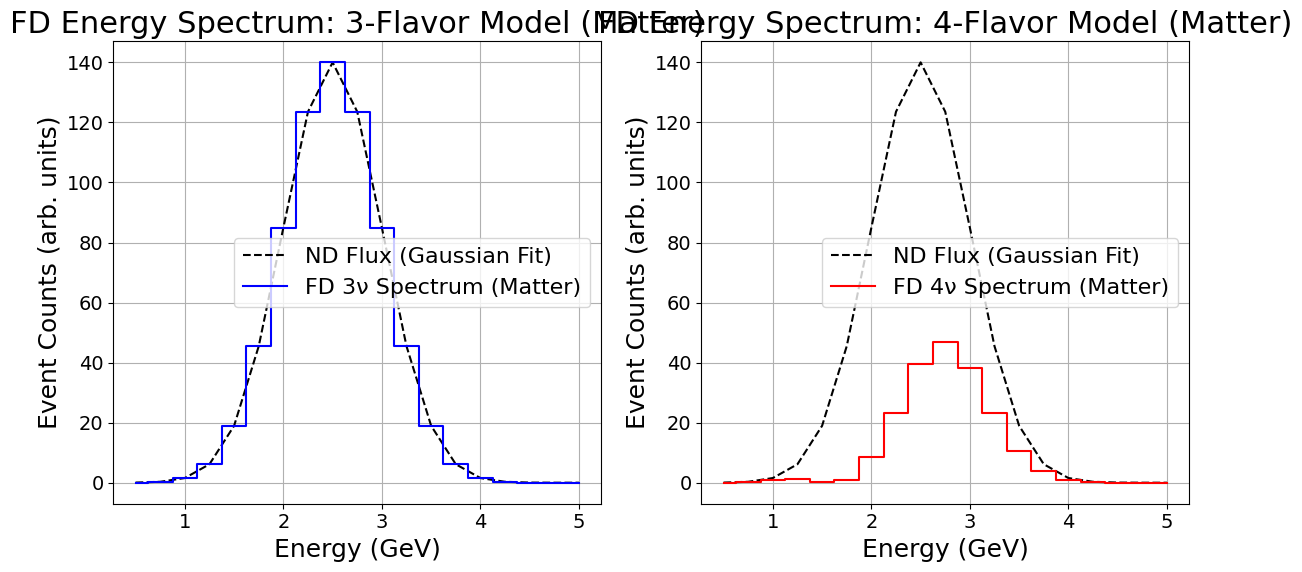

In [ ]:
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# Define a Gaussian function for the ND flux.
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Example ND fit parameters (for flux vs energy in eV) – replace these with your actual values.
popt_nd = [140, 2.5e9, 0.5e9]
# Define bin centers and bin edges (in eV) – here, roughly 0.5 to 5 GeV.
bin_centers = np.linspace(0.5e9, 5e9, 19)
bin_edges = np.linspace(0.5e9, 5e9, 20)

# Define the FD baseline.
Length_far = 810  # km

# Compute the 3ν FD energy spectrum.
# For each energy bin, the "flux" is the ND Gaussian times the oscillation probability.
fd_spec_3nu = np.array([gaussian(E, *popt_nd) * probability_3nu(E, Length_far, transition='mm', matter=True)
                          for E in bin_centers])

# (Assume you have your four-flavor functions defined – for instance, as in our previous snippets.)
# The four-flavor probability function (probability_4nu) is assumed to be defined.
def probability_4nu(energy, L, transition='mm', case='vacuum',
                    theta12=theta12, theta13=theta13, theta23=theta23,
                    theta14=theta14, theta24=theta24, theta34=theta34,
                    delta13=delta13, delta14=delta14, D21=D21, D31=D31, D41=D41):
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        H = hamiltonian_4nu_matter(H_vac, energy, VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2
    elif transition == 'ms':
        return np.abs(S[1, 3])**2

# Compute the 4ν FD energy spectrum (muon survival channel).
fd_spec_4nu = np.array([gaussian(E, *popt_nd) * probability_4nu(E, Length_far, transition='mm', case='matter')
                          for E in bin_centers])

# Plot the spectra in two subplots.
plt.figure(figsize=(12,6))

# 3ν FD Spectrum
plt.subplot(1,2,1)
plt.plot(bin_centers / 1e9, gaussian(bin_centers, *popt_nd), 'k--', label='ND Flux (Gaussian Fit)')
plt.step(bin_centers / 1e9, fd_spec_3nu, where='mid', color='blue', label='FD 3ν Spectrum (Matter)')
plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts (arb. units)")
plt.title("FD Energy Spectrum: 3-Flavor Model (Matter)")
plt.legend()
plt.grid(True)

# 4ν FD Spectrum
plt.subplot(1,2,2)
plt.plot(bin_centers / 1e9, gaussian(bin_centers, *popt_nd), 'k--', label='ND Flux (Gaussian Fit)')
plt.step(bin_centers / 1e9, fd_spec_4nu, where='mid', color='red', label='FD 4ν Spectrum (Matter)')
plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts (arb. units)")
plt.title("FD Energy Spectrum: 4-Flavor Model (Matter)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


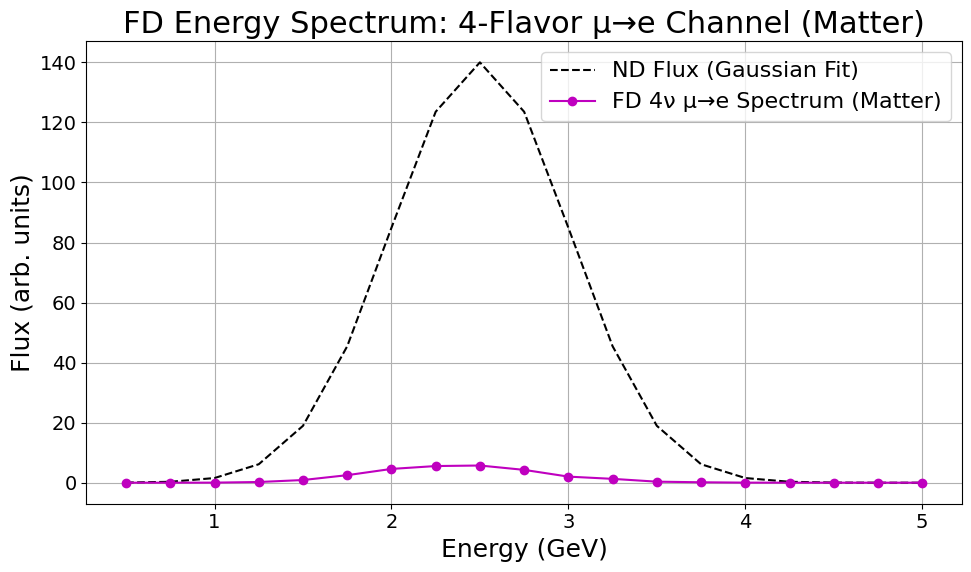

In [ ]:
# Compute the 4ν FD energy spectrum for the μ→e channel with matter effects.
fd_spec_4nu_me = np.array([gaussian(E, *popt_nd) * probability_4nu(E, Length_far, transition='me', case='matter')
                             for E in bin_centers])

plt.figure(figsize=(10,6))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux (Gaussian Fit)")
plt.plot(bin_centers/1e9, fd_spec_4nu_me, 'm-', marker='o', label="FD 4ν μ→e Spectrum (Matter)")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("FD Energy Spectrum: 4-Flavor μ→e Channel (Matter)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


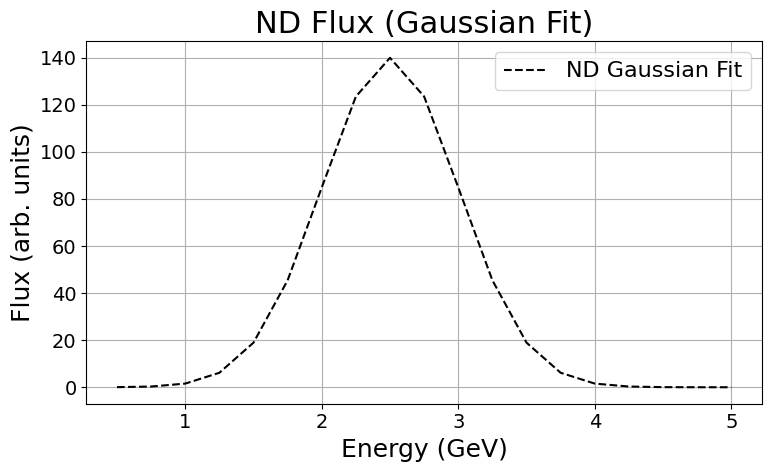

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Global conversion constants (these should match your globaldefs)
CONV_KM_TO_INV_EV = 5.067731e9    # Converts km to inverse eV
VCC_EARTH_CRUST   = 7.6e-14       # Matter potential, e.g., from Earth's crust

# Standard three-flavor parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0                     # CP phase (set to 0; modify to test CP variations)
D21     = 7.39e-5               # eV^2 (solar)
D31     = 2.525e-3              # eV^2 (atmospheric)

# Additional four-flavor parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0                     # Extra CP phase for sterile part
D41     = 1.0                   # eV^2 (sterile)

# Near Detector (ND) flux parameters
# For example, these popt_nd are obtained by fitting the ND data to a Gaussian:
popt_nd = [140, 2.5e9, 0.5e9]    # [Amplitude, Mean (eV), Sigma (eV)]
# Define energy bin centers and edges for ND flux (in eV)
bin_centers = np.linspace(0.5e9, 5e9, 19)  # 0.5 to 5 GeV in eV
bin_edges   = np.linspace(0.5e9, 5e9, 20)

# Define the Gaussian function used for the ND flux fit:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# (Optionally, you can plot the ND flux to verify)
plt.figure(figsize=(8,5))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Gaussian Fit")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("ND Flux (Gaussian Fit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Define the FD baseline (Far Detector at 810 km)
Length_far = 810

# Define the energy range used for FD spectrum plots (in GeV and convert to eV)
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9
